In [ ]:
# file for testing code
# from bouquet import GEQDSKEquilibrium # need bouquet as dependency, "pip install bouquet"

import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import RectBivariateSpline, interp1d

EPEDNN testing

In [ ]:
from juliacall import Main as jl

In [ ]:
# 1. Load the Julia EPEDNN module (Assuming EPEDNN is already installed in your Julia environment)
'''
# To install EPEDNN, run the following command in your terminal:
conda activate sc_ped
cd /Users/nelsonlab/codes/saarelma-conner-ped
julia

# if you need to install julia, run the following command in your terminal:
curl -fsSL https://install.julialang.org | sh
# then restart terminal
julia --version
# if this doesn't work, you could try the following although I did not verify this works:
echo 'export PATH="$HOME/.juliaup/bin:$PATH"' >> ~/.zshrc
source ~/.zshrc
julia --version

# Then in Julia:
using Pkg
Pkg.activate(".")  # optional but recommended: use this repo as the active Julia project
Pkg.develop(path="dependencies/EPEDNN.jl")
Pkg.instantiate()

#Then in Julia: 
using EPEDNN

'''
# you can run Julia commands in Python using jl.seval('command')
jl.seval('using Pkg')
jl.seval('Pkg.activate(".")  # optional but recommended: use this repo as the active Julia project')
jl.seval('Pkg.develop(path="../dependencies/EPEDNN.jl")')
jl.seval('Pkg.instantiate()')
jl.seval('using EPEDNN')

In [ ]:
# 2. Load the pre-trained EPED neural network model
# This mimics the EPEDNN.loadmodelonce("EPED1NNmodel.bson") step
model_filename = "EPED1NNmodel.bson" 
eped_model = jl.EPEDNN.loadmodelonce(model_filename)


In [ ]:
# 3. Define your inputs in Python
# These map exactly to the InputEPED struct we saw in the Julia code
inputs = {
    "a": 0.5,           # Minor radius (m)
    "betan": 2.0,       # Normalized beta
    "bt": 2.5,          # Toroidal magnetic field (T)
    "delta": 0.3,       # Effective triangularity
    "ip": 1.0,          # Plasma current (MA)
    "kappa": 1.7,       # Elongation
    "m": 2.0,           # Effective mass (must be 2.0 for D or 2.5 for D-T)
    "neped": 5.0,       # Pedestal density (in 10^19 m^-3)
    "r": 1.5,           # Major radius (m)
    "zeffped": 1.5      # Effective charge
}

In [ ]:
# 4. Call the Julia model using the Python inputs
# We pass the inputs into the Julia function, along with the keyword arguments
solution = eped_model(
    inputs["a"], 
    inputs["betan"], 
    inputs["bt"], 
    inputs["delta"],
    inputs["ip"], 
    inputs["kappa"], 
    inputs["m"], 
    inputs["neped"],
    inputs["r"], 
    inputs["zeffped"],
    only_powerlaw=False,        # Set to True if you only want the scaling law
    warn_nn_train_bounds=True   # Warns if inputs are outside the training data
)

In [ ]:
# 5. Extract the results back into Python
# The solution structure has pressure and width for different modes (GH, G, H)
pedestal_pressure = solution.pressure.GH.H  # in MPa
pedestal_width = solution.width.GH.H        # in normalized poloidal flux

print(f"Predicted Pedestal Pressure: {pedestal_pressure:.4f} MPa")
print(f"Predicted Pedestal Width: {pedestal_width:.4f}")

EQDSK File Reading

In [ ]:
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk
eq = read_eqdsk('g192185.02440')

In [ ]:
print(eq.keys())
'''
print(eq['case'])
print(eq['nr'])
print(eq['nz'])
print(eq['rdim'])
print(eq['zdim'])
print(eq['rcentr'])
print(eq['rleft'])
print(eq['zmid'])
print(eq['raxis'])
print(eq['zaxis'])
print(eq['psimag'])
print(eq['psirz']) # psi_pol at each RZ grid point, shape (rdim, zdim)
'''

In [ ]:
print(eq['rzout'])


In [ ]:
# contour plot of psi_pol
import matplotlib.pyplot as plt
import numpy as np
# plt.contour(np.linspace(eq['rleft'],eq['rleft']+eq['rdim'],eq['nr']), np.linspace(eq['zmid']-eq['zdim'],eq['zmid']+eq['zdim'],eq['nz']), eq['psirz'])

plt.plot(eq['rzlim'][:,0], eq['rzlim'][:,1], 'kx',label='rzlim')

plt.plot(eq['rzout'][:,0], eq['rzout'][:,1], 'ro',label='rzout')

plt.legend()
plt.show()


In [ ]:
from tkinter.constants import NONE
import numpy as np
import matplotlib.pyplot as plt

r = np.linspace(eq["rleft"], eq["rleft"] + eq["rdim"], eq["nr"])
z = np.linspace(eq["zmid"] - eq["zdim"], eq["zmid"] + eq["zdim"], eq["nz"])

cs = plt.contour(r, z, eq["psirz"],levels=[eq['psibry']])
plt.xlabel('R (m)')
plt.ylabel('Z (m)')

level = cs.levels[0]          # should match psi_b (see note below)
segments = cs.allsegs[0]     # list of (N, 2) arrays, columns are r, z

segments = np.vstack(segments)   # not np.array(...)
segments = segments[np.argsort(segments[:, 1])]

iz = np.argmin(np.abs(segments[:, 1] - eq["zaxis"]))

seg_mod = np.delete(segments, iz, axis=0)

iz1 = np.argmin(np.abs(seg_mod[:, 1] - eq["zaxis"]))

if iz1-iz>=0: # likely this will always be true
    iz1 = iz1+1

tol = 0.1 # closed flux surfaces are at least 10 cm wide
assert abs(segments[iz1,0]) - abs(segments[iz,0]) < tol, "Error: did not find outer and inner separatrix points"

if segments[iz,0] > eq['raxis']:
    iz = iz1 # choose the inboard separatrix point

# up to here you can select the inboard or outboard separatrix point
# but tracing the separatrix is not yet implemented, it is quite complex


print(segments[iz+1:,0])

itop = NONE
for i in range(iz+1,len(segments)):
    if abs(segments[i,0]) < abs(segments[i-1,0]): # if the R coordinate is decreases in absolute magnitude and is to the left of the magnetic axis, we have left the separatrix
        itop = i
        break

ibot = None
for i in range(iz-1,0):
    if abs(segments[i,0]) < abs(segments[i+1,0]): # if the R coordinate is decreases in absolute magnitude and is to the left of the magnetic axis, we have left the separatrix
        ibot = i
        break

if itop is not None and ibot is not None:
    segments = segments[ibot:itop]

# plot the segments
plt.plot(segments[:,0], segments[:,1], 'kx')
plt.show()



In [ ]:

sep = find_separatrix_points(eq)

print(f"Configuration type: {sep['type']}")
print(f"Top    (R, Z) = ({sep['top'][0]:.4f}, {sep['top'][1]:.4f})")
print(f"Bottom (R, Z) = ({sep['bottom'][0]:.4f}, {sep['bottom'][1]:.4f})")
if sep['xpoints']:
    for i, xpt in enumerate(sep['xpoints']):
        print(f"X-point {i+1}: (R, Z) = ({xpt[0]:.4f}, {xpt[1]:.4f})")

r_grid = np.linspace(eq["rleft"], eq["rleft"] + eq["rdim"], eq["nr"])
z_grid = np.linspace(eq["zmid"] - eq["zdim"]/2, eq["zmid"] + eq["zdim"]/2, eq["nz"])

fig, ax = plt.subplots()
ax.contour(r_grid, z_grid, eq["psirz"], levels=30, colors='gray', linewidths=0.5)
ax.contour(r_grid, z_grid, eq["psirz"], levels=[eq['psibry']], colors='blue', linewidths=1.5)
ax.plot(eq['raxis'], eq['zaxis'], 'go', markersize=8, label='O-point (axis)')

ax.plot(*sep['top'], 'rv', markersize=10, label=f"Top ({sep['type']})")
ax.plot(*sep['bottom'], 'r^', markersize=10, label=f"Bottom ({sep['type']})")

for xpt in sep['xpoints']:
    ax.plot(*xpt, 'rx', markersize=12, markeredgewidth=2)


ax.plot(sep['outboard'][0], sep['outboard'][1], 'rx', markersize=10, label='Outboard')
ax.plot(sep['inboard'][0], sep['inboard'][1], 'gx', markersize=10, label='Inboard')

ax.plot(eq['rzout'][:,0], eq['rzout'][:,1], 'ro',label='rzout')

ax.set_xlabel('R (m)')
ax.set_ylabel('Z (m)')
ax.set_aspect('equal')
# ax.legend()

ax.plot(out['top'][0], out['top'][1], 'bv', markersize=15, label='Top')
ax.plot(out['bottom'][0], out['bottom'][1], 'b^', markersize=15, label='Bottom')
ax.plot(out['outboard'][0], out['outboard'][1], 'bx', markersize=15, label='Outboard')
ax.plot(out['inboard'][0], out['inboard'][1], 'bx', markersize=15, label='Inboard')


plt.title(f"Separatrix analysis: {sep['type']}")
plt.show()

In [ ]:
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import fsolve


def find_separatrix_points(eq, psi_tol=0.3):
    """Find X-points (if they exist) or the top/bottom extrema of the separatrix.

    Handles single-null, double-null, and limiter (no null) configurations.
    Uses 2D spline interpolation of psi(R,Z) to locate critical points of the
    poloidal flux, classifies them via the Hessian determinant, then selects
    the best X-point in each hemisphere (above/below magnetic axis) by ranking
    how close each saddle point's psi is to psi_boundary.

    Parameters
    ----------
    eq : dict
        Equilibrium dictionary returned by ``read_eqdsk``.  Must contain
        keys: ``nr``, ``nz``, ``rleft``, ``rdim``, ``zmid``, ``zdim``,
        ``psirz``, ``raxis``, ``zaxis``, ``psimag``, ``psibry``.
        Optionally ``rzout`` (boundary R,Z points).
    psi_tol : float
        Maximum allowed ``|psi_norm - 1|`` for an X-point to be considered
        a separatrix X-point at all.  Acts as a loose sanity-check; within
        each hemisphere the candidate closest to psi_boundary is always
        preferred.  Default 0.3.

    Returns
    -------
    result : dict
        ``'type'``     – ``'double_null'``, ``'single_null'``, or ``'limiter'``
        ``'xpoints'``  – list of ``(R, Z)`` tuples for separatrix X-points
        ``'top'``      – ``(R, Z)`` of the upper X-point or upper separatrix extremum
        ``'bottom'``   – ``(R, Z)`` of the lower X-point or lower separatrix extremum
    """
    nr = eq['nr']
    nz = eq['nz']
    r = np.linspace(eq['rleft'], eq['rleft'] + eq['rdim'], nr)
    z = np.linspace(eq['zmid'] - eq['zdim'], eq['zmid'] + eq['zdim'], nz)
    psi = eq['psirz']
    zaxis = eq['zaxis']
    psimag = eq['psimag']
    psibry = eq['psibry']

    # ---- 2-D spline interpolation  (psi has shape (nz, nr) -> x=z, y=r) ----
    spl = RectBivariateSpline(z, r, psi)

    def _grad(point):
        """Return [dpsi/dR, dpsi/dZ] at a single (R, Z) point."""
        R, Z = point
        dR = float(spl(Z, R, dx=0, dy=1, grid=False))
        dZ = float(spl(Z, R, dx=1, dy=0, grid=False))
        return [dR, dZ]

    # ---- locate candidate critical points via sign changes on the grid ----
    dpsidR = spl(z, r, dx=0, dy=1)   # shape (nz, nr)
    dpsidZ = spl(z, r, dx=1, dy=0)

    candidates = []
    for iz in range(nz - 1):
        for ir in range(nr - 1):
            corners_dR = [dpsidR[iz, ir], dpsidR[iz, ir+1],
                          dpsidR[iz+1, ir], dpsidR[iz+1, ir+1]]
            corners_dZ = [dpsidZ[iz, ir], dpsidZ[iz, ir+1],
                          dpsidZ[iz+1, ir], dpsidZ[iz+1, ir+1]]
            signs_dR = set(np.sign(v) for v in corners_dR if v != 0.0)
            signs_dZ = set(np.sign(v) for v in corners_dZ if v != 0.0)
            if len(signs_dR) > 1 and len(signs_dZ) > 1:
                candidates.append((0.5*(r[ir]+r[ir+1]),
                                   0.5*(z[iz]+z[iz+1])))

    # ---- refine & classify each candidate ----
    xpoints = []
    opoints = []
    found = []

    for R0, Z0 in candidates:
        try:
            sol, _, ier, _ = fsolve(_grad, [R0, Z0], full_output=True)
        except Exception:
            continue
        if ier != 1:
            continue
        Rs, Zs = sol
        if Rs < r[0] or Rs > r[-1] or Zs < z[0] or Zs > z[-1]:
            continue
        residual = _grad(sol)
        if abs(residual[0]) > 1e-6 or abs(residual[1]) > 1e-6:
            continue
        if any(abs(Rs - Rf) < 0.01 and abs(Zs - Zf) < 0.01
               for Rf, Zf in found):
            continue
        found.append((Rs, Zs))

        # Hessian determinant distinguishes saddle (X) from extremum (O)
        d2R2 = float(spl(Zs, Rs, dx=0, dy=2, grid=False))
        d2Z2 = float(spl(Zs, Rs, dx=2, dy=0, grid=False))
        d2RZ = float(spl(Zs, Rs, dx=1, dy=1, grid=False))
        det_H = d2R2 * d2Z2 - d2RZ**2

        if det_H < 0:
            xpoints.append((Rs, Zs))
        else:
            opoints.append((Rs, Zs))

    # ---- rank X-points by proximity to psi_boundary, per hemisphere ----
    psi_range = abs(psibry - psimag)
    upper_xpts = []   # (R, Z, psi_error)  for Z > zaxis
    lower_xpts = []   # (R, Z, psi_error)  for Z < zaxis

    for Rx, Zx in xpoints:
        psi_norm = abs(float(spl(Zx, Rx, grid=False)) - psimag) / psi_range
        psi_err = abs(psi_norm - 1.0)
        if psi_err > psi_tol:
            continue
        if Zx > zaxis:
            upper_xpts.append((Rx, Zx, psi_err))
        else:
            lower_xpts.append((Rx, Zx, psi_err))

    best_upper = min(upper_xpts, key=lambda x: x[2]) if upper_xpts else None
    best_lower = min(lower_xpts, key=lambda x: x[2]) if lower_xpts else None

    sep_xpoints = []
    if best_upper is not None:
        sep_xpoints.append((best_upper[0], best_upper[1]))
    if best_lower is not None:
        sep_xpoints.append((best_lower[0], best_lower[1]))

    # ---- helper: extrema from boundary contour or rzout ----
    def _boundary_extrema():
        """Return top, bottom, outboard, inboard (R,Z) extrema of the separatrix."""
        if 'rzout' in eq and eq['rzout'] is not None and len(eq['rzout']) > 0:
            bdy = eq['rzout']
        else:
            import matplotlib
            matplotlib.use('Agg')
            fig, ax = plt.subplots()
            cs = ax.contour(r, z, psi, levels=[psibry])
            bdy = np.vstack(cs.allsegs[0])
            plt.close(fig)
        itop = np.argmax(bdy[:, 1])
        ibot = np.argmin(bdy[:, 1])
        iout = np.argmax(bdy[:, 0])
        iin  = np.argmin(bdy[:, 0])
        top      = (bdy[itop, 0], bdy[itop, 1])
        bottom   = (bdy[ibot, 0], bdy[ibot, 1])
        outboard = (bdy[iout, 0], bdy[iout, 1])
        inboard  = (bdy[iin,  0], bdy[iin,  1])
        return top, bottom, outboard, inboard

    # ---- assemble result ----
    result = {'xpoints': sep_xpoints, 'opoints': opoints}
    top_bdy, bot_bdy, out_bdy, in_bdy = _boundary_extrema()
    result['outboard'] = out_bdy
    result['inboard']  = in_bdy

    if len(sep_xpoints) == 0:
        result['type'] = 'limiter'
        result['top'] = top_bdy
        result['bottom'] = bot_bdy

    elif len(sep_xpoints) == 1:
        result['type'] = 'single_null'
        xpt = sep_xpoints[0]
        if xpt[1] > zaxis:
            result['top'] = xpt
            result['bottom'] = bot_bdy
        else:
            result['bottom'] = xpt
            result['top'] = top_bdy

    else:
        result['type'] = 'double_null'
        sep_xpoints.sort(key=lambda p: p[1])
        result['bottom'] = sep_xpoints[0]
        result['top'] = sep_xpoints[-1]

    return result


In [ ]:
def plasma_surface_area_and_volume(eq):
    """Compute the surface area and volume of the plasma bounded by the separatrix.

    Treats the boundary as a closed polygon in (R, Z) revolved around the
    Z-axis (toroidal symmetry).  Uses eq['rzout'] as the boundary points.

    Parameters
    ----------
    eq : dict
        Equilibrium dictionary from read_eqdsk (must contain 'rzout').

    Returns
    -------
    dict with keys:
        'volume'              – plasma volume (m^3)
        'surface_area'        – toroidal surface area (m^2)
        'cross_section_area'  – poloidal cross-section area (m^2)
    """
    bdy = eq['rzout']
    R = bdy[:, 0]
    Z = bdy[:, 1]

    # Close the polygon if the first and last points don't match
    if not (np.isclose(R[0], R[-1]) and np.isclose(Z[0], Z[-1])):
        R = np.append(R, R[0])
        Z = np.append(Z, Z[0])

    dZ = np.diff(Z)
    dR = np.diff(R)

    R_i  = R[:-1]
    R_ip = R[1:]

    # Poloidal cross-section area  (shoelace formula - general to any polygon)
    # cross_section_area = 0.5 * abs(np.sum(R_i * Z[1:] - R_ip * Z[:-1]))

    # Toroidal volume:  V = (pi/3) |sum (Z_{i+1}-Z_i)(R_i^2 + R_i*R_{i+1} + R_{i+1}^2)|
    # Exact integral of pi*R^2 dZ for piecewise-linear boundary segments
    volume = (np.pi / 3.0) * abs(np.sum(dZ * (R_i**2 + R_i * R_ip + R_ip**2)))

    # Toroidal surface area:  S = 2*pi * sum  R_avg * dl   (Pappus' theorem)
    dl = np.sqrt(dR**2 + dZ**2)
    surface_area = 2.0 * np.pi * np.sum(0.5 * (R_i + R_ip) * dl)

    return {
        'volume': volume,
        'surface_area': surface_area,
        # 'cross_section_area': cross_section_area,
    }


result = plasma_surface_area_and_volume(eq)
print(f"Plasma volume:              {result['volume']:.4f} m^3")
print(f"Toroidal surface area:      {result['surface_area']:.4f} m^2")
print(f"Poloidal cross-section area: {result['cross_section_area']:.4f} m^2")

In [ ]:
kprof_fp = '/Users/nelsonlab/codes/Equilibria/p193754.1850.0'
def read_pfile(path):
    data = {}
    key = ''
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                key = line.split()[2]
                data[key] = np.array([])
                data[f'{key}_psi'] = np.array([])
            else:
                psi, dat, _ = line.split()
                psi = float(psi)
                dat = float(dat)
                data[key] = np.append(data[key], dat)
                data[f'{key}_psi'] = np.append(data[f'{key}_psi'], psi)
    return data

# Extract profiles
pf = read_pfile(kprof_fp)
print(pf.keys())
# n_e = pf.get("ne") 
# T_e = pf.get("te")
n_e = pf['ne(10^20/m^3)'] # n_e values (10^20/m^3) evaluated at psi_ne_eval
T_e = pf['te(KeV)'] # T_e values (KeV) evaluated at psi_Te_eval
psi_ne_eval = pf['ne(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated
psi_Te_eval = pf['te(KeV)_psi'] # psi_N values at which T_e is evaluated

# Calculate boundary condition from profiles at psi_N = 0.85
dne_dx = np.gradient(n_e, psi_ne_eval) # (particles/m^3) / m, electron density gradient

from scipy.interpolate import interp1d

# Create the interpolation function
dne_dx_interp = interp1d(psi_ne_eval, dne_dx, kind='linear')

# Use the function to find new y values
dne_dx_neginf = dne_dx_interp(0.85)
print(dne_dx_neginf)

fig, ax = plt.subplots()
ax.plot(psi_ne_eval, dne_dx, label='dne_dx')
ax.plot(0.85, dne_dx_neginf, 'ro')
ax.plot(psi_ne_eval, n_e, label='n_e')
plt.legend()
plt.show()


In [ ]:
# this is the code from solver.py when I needed to find separatrix points. May come in handy at some point

def find_separatrix_points(eq, psi_tol=0.3):
    """Find X-points (if they exist) or the top/bottom extrema of the separatrix.

    Handles single-null, double-null, and limiter (no null) configurations.
    Uses 2D spline interpolation of psi(R,Z) to locate critical points of the
    poloidal flux, classifies them via the Hessian determinant, then selects
    the best X-point in each hemisphere (above/below magnetic axis) by ranking
    how close each saddle point's psi is to psi_boundary.

    Parameters
    ----------
    eq : dict
        Equilibrium dictionary returned by ``read_eqdsk``.  Must contain
        keys: ``nr``, ``nz``, ``rleft``, ``rdim``, ``zmid``, ``zdim``,
        ``psirz``, ``raxis``, ``zaxis``, ``psimag``, ``psibry``.
        Optionally ``rzout`` (boundary R,Z points).
    psi_tol : float
        Maximum allowed ``|psi_norm - 1|`` for an X-point to be considered
        a separatrix X-point at all.  Acts as a loose sanity-check; within
        each hemisphere the candidate closest to psi_boundary is always
        preferred.  Default 0.3.

    Returns
    -------
    result : dict
        ``'type'``     – ``'double_null'``, ``'single_null'``, or ``'limiter'``
        ``'xpoints'``  – list of ``(R, Z)`` tuples for separatrix X-points
        ``'top'``      – ``(R, Z)`` of the upper X-point or upper separatrix extremum
        ``'bottom'``   – ``(R, Z)`` of the lower X-point or lower separatrix extremum
    """
    nr = eq['nr']
    nz = eq['nz']
    r = np.linspace(eq['rleft'], eq['rleft'] + eq['rdim'], nr)
    z = np.linspace(eq['zmid'] - eq['zdim'], eq['zmid'] + eq['zdim'], nz)
    psi = eq['psirz']
    zaxis = eq['zaxis']
    psimag = eq['psimag']
    psibry = eq['psibry']

    # ---- 2-D spline interpolation  (psi has shape (nz, nr) -> x=z, y=r) ----
    spl = RectBivariateSpline(z, r, psi)

    def _grad(point):
        """Return [dpsi/dR, dpsi/dZ] at a single (R, Z) point."""
        R, Z = point
        dR = float(spl(Z, R, dx=0, dy=1, grid=False))
        dZ = float(spl(Z, R, dx=1, dy=0, grid=False))
        return [dR, dZ]

    # ---- locate candidate critical points via sign changes on the grid ----
    dpsidR = spl(z, r, dx=0, dy=1)   # shape (nz, nr)
    dpsidZ = spl(z, r, dx=1, dy=0)

    candidates = []
    for iz in range(nz - 1):
        for ir in range(nr - 1):
            corners_dR = [dpsidR[iz, ir], dpsidR[iz, ir+1],
                        dpsidR[iz+1, ir], dpsidR[iz+1, ir+1]]
            corners_dZ = [dpsidZ[iz, ir], dpsidZ[iz, ir+1],
                        dpsidZ[iz+1, ir], dpsidZ[iz+1, ir+1]]
            signs_dR = set(np.sign(v) for v in corners_dR if v != 0.0)
            signs_dZ = set(np.sign(v) for v in corners_dZ if v != 0.0)
            if len(signs_dR) > 1 and len(signs_dZ) > 1:
                candidates.append((0.5*(r[ir]+r[ir+1]),
                                0.5*(z[iz]+z[iz+1])))

    # ---- refine & classify each candidate ----
    xpoints = []
    opoints = []
    found = []

    for R0, Z0 in candidates:
        try:
            sol, _, ier, _ = fsolve(_grad, [R0, Z0], full_output=True)
        except Exception:
            continue
        if ier != 1:
            continue
        Rs, Zs = sol
        if Rs < r[0] or Rs > r[-1] or Zs < z[0] or Zs > z[-1]:
            continue
        residual = _grad(sol)
        if abs(residual[0]) > 1e-6 or abs(residual[1]) > 1e-6:
            continue
        if any(abs(Rs - Rf) < 0.01 and abs(Zs - Zf) < 0.01
            for Rf, Zf in found):
            continue
        found.append((Rs, Zs))

        # Hessian determinant distinguishes saddle (X) from extremum (O)
        d2R2 = float(spl(Zs, Rs, dx=0, dy=2, grid=False))
        d2Z2 = float(spl(Zs, Rs, dx=2, dy=0, grid=False))
        d2RZ = float(spl(Zs, Rs, dx=1, dy=1, grid=False))
        det_H = d2R2 * d2Z2 - d2RZ**2

        if det_H < 0:
            xpoints.append((Rs, Zs))
        else:
            opoints.append((Rs, Zs))

    # ---- rank X-points by proximity to psi_boundary, per hemisphere ----
    psi_range = abs(psibry - psimag)
    upper_xpts = []   # (R, Z, psi_error)  for Z > zaxis
    lower_xpts = []   # (R, Z, psi_error)  for Z < zaxis

    for Rx, Zx in xpoints:
        psi_norm = abs(float(spl(Zx, Rx, grid=False)) - psimag) / psi_range
        psi_err = abs(psi_norm - 1.0)
        if psi_err > psi_tol:
            continue
        if Zx > zaxis:
            upper_xpts.append((Rx, Zx, psi_err))
        else:
            lower_xpts.append((Rx, Zx, psi_err))

    best_upper = min(upper_xpts, key=lambda x: x[2]) if upper_xpts else None
    best_lower = min(lower_xpts, key=lambda x: x[2]) if lower_xpts else None

    sep_xpoints = []
    if best_upper is not None:
        sep_xpoints.append((best_upper[0], best_upper[1]))
    if best_lower is not None:
        sep_xpoints.append((best_lower[0], best_lower[1]))

    # ---- helper: extrema from boundary contour or rzout ----
    def _boundary_extrema():
        """Return top, bottom, outboard, inboard (R,Z) extrema of the separatrix."""
        if 'rzout' in eq and eq['rzout'] is not None and len(eq['rzout']) > 0:
            bdy = eq['rzout']
        else:
            import matplotlib
            matplotlib.use('Agg')
            fig, ax = plt.subplots()
            cs = ax.contour(r, z, psi, levels=[psibry])
            bdy = np.vstack(cs.allsegs[0])
            plt.close(fig)
        itop = np.argmax(bdy[:, 1])
        ibot = np.argmin(bdy[:, 1])
        iout = np.argmax(bdy[:, 0])
        iin  = np.argmin(bdy[:, 0])
        top      = (bdy[itop, 0], bdy[itop, 1])
        bottom   = (bdy[ibot, 0], bdy[ibot, 1])
        outboard = (bdy[iout, 0], bdy[iout, 1])
        inboard  = (bdy[iin,  0], bdy[iin,  1])
        return top, bottom, outboard, inboard

    # ---- assemble result ----
    result = {'xpoints': sep_xpoints, 'opoints': opoints}
    top_bdy, bot_bdy, out_bdy, in_bdy = _boundary_extrema()
    result['outboard'] = out_bdy
    result['inboard']  = in_bdy

    if len(sep_xpoints) == 0:
        result['type'] = 'limiter'
        result['top'] = top_bdy
        result['bottom'] = bot_bdy

    elif len(sep_xpoints) == 1:
        result['type'] = 'single_null'
        xpt = sep_xpoints[0]
        if xpt[1] > zaxis:
            result['top'] = xpt
            result['bottom'] = bot_bdy
        else:
            result['bottom'] = xpt
            result['top'] = top_bdy

    else:
        result['type'] = 'double_null'
        sep_xpoints.sort(key=lambda p: p[1])
        result['bottom'] = sep_xpoints[0]
        result['top'] = sep_xpoints[-1]

    return result


In [ ]:
def find_boundary_points(eq):
    """Find the top/bottom/inboard/outboard extrema of the separatrix.

    Parameters
    ----------
    eq : dict
        Equilibrium dictionary returned by ``read_eqdsk``.  Must contain
        keys: ``nr``, ``nz``, ``rleft``, ``rdim``, ``zmid``, ``zdim``,
        ``psirz``, ``raxis``, ``zaxis``, ``psimag``, ``psibry``.
        Optionally ``rzout`` (boundary R,Z points).

    Returns
    -------
    result : dict
        ``'top'``      – ``(R, Z)`` of the upper boundary point
        ``'bottom'``   – ``(R, Z)`` of the lower boundary point
        ``'outboard'``  – ``(R, Z)`` of the outboard boundary point
        ``'inboard'``   – ``(R, Z)`` of the inboard boundary point
    """

    psi = eq['psirz']
    psibry = eq['psibry']

    if 'rzout' in eq and eq['rzout'] is not None and len(eq['rzout']) > 0:
        bdy = eq['rzout']
    else:
        nr = eq['nr']
        nz = eq['nz']
        r = np.linspace(eq['rleft'], eq['rleft'] + eq['rdim'], nr)
        z = np.linspace(eq['zmid'] - eq['zdim']/2, eq['zmid'] + eq['zdim']/2, nz)
        import matplotlib
        matplotlib.use('Agg')
        fig, ax = plt.subplots()
        cs = ax.contour(r, z, psi, levels=[psibry])
        bdy = np.vstack(cs.allsegs[0])
        plt.close(fig)
    itop = np.argmax(bdy[:, 1])
    ibot = np.argmin(bdy[:, 1])
    iout = np.argmax(bdy[:, 0])
    iin  = np.argmin(bdy[:, 0])
    top      = (bdy[itop, 0], bdy[itop, 1])
    bottom   = (bdy[ibot, 0], bdy[ibot, 1])
    outboard = (bdy[iout, 0], bdy[iout, 1])
    inboard  = (bdy[iin,  0], bdy[iin,  1])

    return {
        'top': top,
        'bottom': bottom,
        'outboard': outboard,
        'inboard': inboard,
    }

In [ ]:
out = find_boundary_points(eq)

In [ ]:
from adas.adas_ionisation import scd_adas

test = scd_adas([10**20],[100])
print(test)


In [ ]:
def fsa(self, A, flux_surfaces='T_e'):
    R_axis = self.eq['raxis']
    Z_axis = self.eq['zaxis']

    if flux_surfaces == 'T_e':
        psi_N_vals = self.psi_Te_eval
    else:
        assert False, 'valid flux_surfaces method must be provided'

    A_spl = RectBivariateSpline(self.zgrid, self.rgrid, A)
    fsa_A = np.full(len(psi_N_vals), np.nan)

    fig, ax = plt.subplots()
    for i, psi_val in enumerate(psi_N_vals):
        if psi_val <= 0.01 or psi_val >= 0.99:
            continue

        ax.cla()
        cs = ax.contour(self.rgrid, self.zgrid, self.psi_RZ_N,
                        levels=[psi_val])

        segs = cs.allsegs[0]
        if not segs:
            continue

        # longest contour = the real flux surface, not islands
        seg = max(segs, key=lambda s: len(s))
        R_c, Z_c = seg[:, 0], seg[:, 1] # R, Z coordinates of the contour

        # poloidal angle measured from the magnetic axis
        R_c_ax = (((R_c - R_axis)**2) + ((Z_c - Z_axis)**2))**0.5
        theta_c = np.arcsin( (Z_c - Z_axis) / R_c_ax )
        idx = np.argsort(theta_c)
        theta_c, R_c, Z_c = theta_c[idx], R_c[idx], Z_c[idx]

        # close the contour so the integral spans a full 2*pi
        theta_c = np.append(theta_c, theta_c[0] + 2 * np.pi)
        R_c = np.append(R_c, R_c[0])
        Z_c = np.append(Z_c, Z_c[0])

        A_c = A_spl(Z_c, R_c, grid=False)

        den = np.simpson(R_c**2, theta_c)
        if abs(den) < 1e-30:
            continue
        fsa_A[i] = np.simpson(R_c**2 * A_c, theta_c) / den

    plt.close(fig)
    return fsa_A

MODEL TESTING

In [1]:
from solver import saarelma_connor
test_model = saarelma_connor(
        P_tot_e = 5e6, # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
        alpha_crit = 1,
        C_KBM = 0.1,
        De_chie_etg = 0.5,
        mhd_fp = 'g192185.02440', # filepath to MHD paramter file
        kprof_fp = '/Users/nelsonlab/codes/Equilibria/p193754.1850.0', # filepath to kinetic paramter file
)

In [2]:
test_model.solve(x_res=100)

iteration:  0
A : 162.51522188950412, min: 37.40072992547421
B : -8.559457269907465, min: -37.1929130860433
K : 3.3021451484457263, min: -1.8651630662279646
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
iteration:  0
A : 162.51522188950412, min: 37.40072992547421
B : -8.559457269907465, min: -37.1929130860433
K : 3.3021451484457263, min: -1.8651630662279646
iteration:  0
A : 162.2266391708902, min: 38.87334994669611
B : -8.89647818291039, min: -37.12686861435166
K : 3.346051850794246, min: -1.870034649841886
iteration:  0
A : 162.51522188950412, min: 37.40072992547421
B : -8.559457269907465, min: -37.1929130860433
K : 3.3021451484457263, min: -1.8651630662279646
iteration:  0
A : 162.51522188950412, min: 37.40072992547421
B : -8.559457269907465, min: -37.1929130860433
K : 3.3021451484457263, min: -1.8651630662279646
iteration:  0
A : 162.2266391708902, min: 38.87334994669611
B : -8.89647818291039, min: -37.12686861435166
K : 3.346051850794246, min: -1.8700

RuntimeError: step 1 BVP failed: The maximum number of mesh nodes is exceeded.

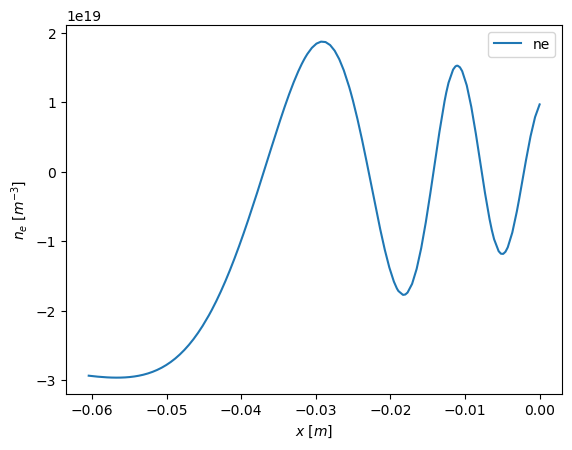

dne_dx at pedestal peak:  -1.297866217353967e+20


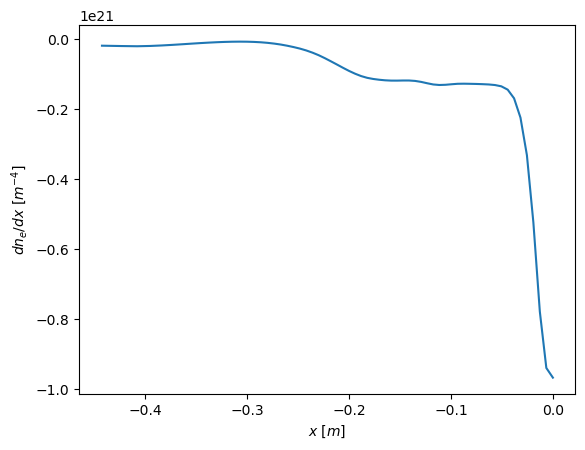

In [3]:
# non-converged debugging
import matplotlib.pyplot as plt
import numpy as np

x = test_model.sol.x
y = test_model.sol.y[0]
dy = test_model.sol.y[1]
fig,ax = plt.subplots()
ax.plot(x,y,label='ne')
# ax.plot(x,dy,label='dne_dx')
ax.set_xlabel(r'$x$ [$m$]')
ax.set_ylabel(r'$n_e$ [$m^{-3}$]')
plt.legend()
plt.show()

print('dne_dx at pedestal peak: ',test_model.dne_dx_neginf)
fig1,ax1 = plt.subplots()
ax1.plot(test_model.x_init,np.gradient(test_model.n_e_pres,test_model.x_init))
ax1.set_xlabel(r'$x$ [$m$]')
ax1.set_ylabel(r'$dn_e/dx$ [$m^{-4}$]')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
x_sol = test_model.x_sol
ne_sol = test_model.ne_sol
dne_dx_sol = test_model.dne_dx_sol

In [ ]:
fig,ax = plt.subplots()
ax.plot(x_sol,ne_sol,label='ne')
# ax.plot(x_sol,dne_dx_sol,label='dne_dx')
ax.set_xlabel(r'$x$ [$m$]')
ax.set_ylabel(r'$n_e$ [$m^{-3}$]')
plt.legend()
plt.show()

In [ ]:
nFC_sol = test_model.nFC_x0 * test_model.exp_term_arr
plt.plot(test_model.x_sol,test_model.exp_term_arr)
plt.xlabel(r'$x$ [$m$]')
plt.ylabel(r'$n_{FC}$ [$m^{-3}$]')
plt.show()




GRAD(r) TESTING

In [ ]:
"""Compute <|grad(r)|> at each flux surface.

r is defined as the outboard-midplane minor radius for each flux
surface, making it a proper flux-surface label (one value per surface).
By the chain rule:
    |grad(r)| = |dr/dpsi| * |grad(psi)|
This varies poloidally because |grad(psi)| is larger where flux
surfaces are compressed (inboard side) and smaller where they are
spread apart (outboard side).

The flux surface average is:
    <|grad(r)|> = ∮ R² |grad(r)| dθ / ∮ R² dθ

Sets
----
self.r_psi : ndarray, shape (n_psi,)
    Outboard midplane minor radius for each flux surface (m).
self.gradr_fsa : ndarray, shape (n_psi,)
    Flux-surface-averaged |grad(r)| at each psi_N_pres surface.
"""
R_axis = test_model.eq['raxis']
Z_axis = test_model.eq['zaxis']

psi_spl = RectBivariateSpline(test_model.zgrid, test_model.rgrid, test_model.psi_RZ)
n_psi = len(test_model.psi_N_pres)

# r(psi): find outboard midplane crossing for each flux surface
R_out = np.linspace(R_axis, test_model.rgrid[-1], 500)
Z_mid = np.full_like(R_out, Z_axis)
psi_mid = psi_spl(Z_mid, R_out, grid=False)
sort_idx = np.argsort(psi_mid)
psi_to_R = interp1d(psi_mid[sort_idx], R_out[sort_idx], kind='linear',
                    bounds_error=False, fill_value=np.nan)

test_model.r_psi = np.zeros(n_psi)
for i, psi_val in enumerate(test_model.psi_N_pres):
    test_model.r_psi[i] = psi_to_R(psi_val) - R_axis

dr_dpsi = np.gradient(test_model.r_psi, test_model.psi_N_pres) # (m) / (dimensionless), change in r_midplane(psi_N) over psi_N



In [ ]:
print(test_model.r_psi)

In [ ]:
"""Compute <|grad(r)|> at each flux surface.

r is defined as the outboard-midplane minor radius for each flux
surface, making it a proper flux-surface label (one value per surface).
By the chain rule:
    |grad(r)| = |dr/dpsi| * |grad(psi)|
This varies poloidally because |grad(psi)| is larger where flux
surfaces are compressed (inboard side) and smaller where they are
spread apart (outboard side).

The flux surface average is:
    <|grad(r)|> = ∮ R² |grad(r)| dθ / ∮ R² dθ

Sets
----
self.r_psi : ndarray, shape (n_psi,)
    Outboard midplane minor radius for each flux surface (m).
self.gradr_fsa : ndarray, shape (n_psi,)
    Flux-surface-averaged |grad(r)| at each psi_N_pres surface.
"""
R_axis = test_model.eq['raxis']
Z_axis = test_model.eq['zaxis']

psi_spl = RectBivariateSpline(test_model.zgrid, test_model.rgrid, test_model.psi_RZ)
n_psi = len(test_model.psi_N_pres)

# r(psi): find outboard midplane crossing for each flux surface
R_out = np.linspace(R_axis, test_model.rgrid[-1], 500)
Z_mid = np.full_like(R_out, Z_axis)
psi_mid = psi_spl(Z_mid, R_out, grid=False)
sort_idx = np.argsort(psi_mid)
psi_to_R = interp1d(psi_mid[sort_idx], R_out[sort_idx], kind='linear',
                    bounds_error=False, fill_value=np.nan)

test_model.r_psi = np.zeros(n_psi)
for i, psi_val in enumerate(test_model.psi_N_pres):
    test_model.r_psi[i] = psi_to_R(psi_val) - R_axis

dr_dpsi = np.gradient(test_model.r_psi, test_model.psi_N_pres) # (m) / (dimensionless), change in r_midplane(psi_N) over psi_N

test_model.gradr_fsa = np.zeros(n_psi)
test_model.gradr_c = np.zeros(n_psi)
fig, ax = plt.subplots()
for i, psi_val in enumerate(test_model.psi_N_pres):
    ax.cla()
    cs = ax.contour(test_model.rgrid, test_model.zgrid, test_model.psi_RZ,
                    levels=[psi_val])
    segs = cs.allsegs[0]
    if not segs:
        test_model.gradr_fsa[i] = np.nan
        continue

    seg = max(segs, key=lambda s: len(s)) # longest contour = the real flux surface, not islands
    R_c, Z_c = seg[:, 0], seg[:, 1]

    theta_c = np.arctan2(Z_c - Z_axis, R_c - R_axis) # theta at all points on contour
    idx = np.argsort(theta_c)
    theta_c, R_c, Z_c = theta_c[idx], R_c[idx], Z_c[idx]

    theta_c = np.append(theta_c, theta_c[0] + 2 * np.pi)
    R_c = np.append(R_c, R_c[0])
    Z_c = np.append(Z_c, Z_c[0])

    # |grad(psi)| at each contour point from the equilibrium spline
    dpsi_dR = psi_spl(Z_c, R_c, dx=0, dy=1, grid=False) # value at each point on the contour
    dpsi_dZ = psi_spl(Z_c, R_c, dx=1, dy=0, grid=False) # value at each point on the contour
    grad_psi_mag = np.sqrt(dpsi_dR**2 + dpsi_dZ**2) # value at each point on the contour

    # |grad(r)| = |dr/dpsi| * |grad(psi)| at each contour point on each flux surface i
    test = np.abs(dr_dpsi[i]) * grad_psi_mag
plt.close(fig)
# gradr_fsa = fsa(test_model.gradr_c, flux_surfaces='psi_N_pres') # flux surface-averaged |grad(r)| at each psi_N_pres surface


In [ ]:
print(test.shape)
print(dpsi_dR.shape)

In [ ]:
from scipy.interpolate import interp1d

psi_N_pres = np.linspace(0, 1, 10)
psi_N_Te = np.linspace(0, 1, 15)
rmid = np.linspace(0.3, 0.5, 10) # rmid at each psi_N
x = rmid - rmid[-1] # ped coordinate system

Dped_pres = np.linspace(1e5, 1e6, 10) # Dped on the psi_N_pres grid, which is the same as the rmid grid and the x grid
S_i = np.linspace(1e-2,1e-1,15) # S_i on the psi_N_Te grid

# now interpolate S_i to psi_N_pres grid
S_i_pres = interp1d(psi_N_Te, S_i, kind='linear', bounds_error=False, fill_value='extrapolate')
print(S_i_pres(psi_N_pres))


In [ ]:
test = np.array([-1,2,-3])
print(abs(test))